In [1]:
import pandas as pd
import numpy as np

In [6]:
file_path = "../data/online_retail_II.xlsx"

%pip install openpyxl

df = pd.read_excel(file_path, engine="openpyxl")

print("Dataset loaded successfully.")


   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpy


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset loaded successfully.


In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 541910
Number of columns: 8


In [8]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541910 entries, 0 to 541909
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      541910 non-null  object        
 1   StockCode    541910 non-null  object        
 2   Description  540456 non-null  object        
 3   Quantity     541910 non-null  int64         
 4   InvoiceDate  541910 non-null  datetime64[ns]
 5   Price        541910 non-null  float64       
 6   Customer ID  406830 non-null  float64       
 7   Country      541910 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


# Inspecting The Dataset

In [10]:
missing_values = df.isnull().sum()

print(missing_values)

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage.round(2))

Invoice         0.00
StockCode       0.00
Description     0.27
Quantity        0.00
InvoiceDate     0.00
Price           0.00
Customer ID    24.93
Country         0.00
dtype: float64


In [12]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 5268


In [13]:
df[["Quantity", "Price"]].describe()

,Quantity,Price
count,541910.000000,541910.000000
mean,9.552234,4.611138
std,218.080957,96.759765
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [14]:
cancellation_mask = df["Invoice"].astype(str).str.startswith("C")

print("Cancellation transactions:", cancellation_mask.sum())

Cancellation transactions: 9288


In [15]:
df[cancellation_mask].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [16]:
negative_quantity = (df["Quantity"] < 0).sum()

print("Negative quantity transactions:", negative_quantity)

Negative quantity transactions: 10624


In [17]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [18]:
zero_price = (df["Price"] == 0).sum()
negative_price = (df["Price"] < 0).sum()

print("Zero-price transactions:", zero_price)
print("Negative-price transactions:", negative_price)

Zero-price transactions: 2515
Negative-price transactions: 2


In [20]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    errors="coerce"
)

In [21]:
print(df["InvoiceDate"].dtype)

datetime64[ns]


# Perform Cleaning

In [22]:
df_clean = df.dropna(subset=["Customer ID"]).copy()

In [23]:
df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
].copy()

In [24]:
df_clean = df_clean[
    df_clean["Quantity"] > 0
].copy()

In [25]:
df_clean = df_clean[
    df_clean["Price"] > 0
].copy()

In [26]:
df_clean = df_clean.drop_duplicates().copy()

In [27]:
df_clean["Customer ID"] = df_clean["Customer ID"].astype(int)

In [28]:
df_clean["Invoice"] = df_clean["Invoice"].astype(str).str.strip()
df_clean["StockCode"] = df_clean["StockCode"].astype(str).str.strip()

# Verify Clened Dataset

In [29]:
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (541910, 8)
Cleaned shape: (392693, 8)


In [30]:
print(
    "Missing Customer IDs:",
    df_clean["Customer ID"].isna().sum()
)

Missing Customer IDs: 0


In [31]:
remaining_cancellations = (
    df_clean["Invoice"]
    .astype(str)
    .str.startswith("C")
    .sum()
)

print("Remaining cancellation invoices:", remaining_cancellations)

Remaining cancellation invoices: 0


In [32]:
print("Quantity <= 0:", (df_clean["Quantity"] <= 0).sum())
print("Price <= 0:", (df_clean["Price"] <= 0).sum())

Quantity <= 0: 0
Price <= 0: 0


In [33]:
print("Unique customers:", df_clean["Customer ID"].nunique())
print("Unique invoices:", df_clean["Invoice"].nunique())

print(
    "Date range:",
    df_clean["InvoiceDate"].min(),
    "to",
    df_clean["InvoiceDate"].max()
)

Unique customers: 4338
Unique invoices: 18532
Date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00


In [34]:
cleaned_file_path = "../data/online_retail_II_cleaned.csv"

df_clean.to_csv(
    cleaned_file_path,
    index=False
)

print("Cleaned dataset saved to:")
print(cleaned_file_path)

Cleaned dataset saved to:
../data/online_retail_II_cleaned.csv


# Task 2 - Construct Customer Features + Churn Target

In [35]:
max_date = df_clean["InvoiceDate"].max()

print("Maximum transaction date:", max_date)

Maximum transaction date: 2011-12-09 12:50:00


In [36]:
observation_end = max_date - pd.Timedelta(days=90)

print("Observation period ends:", observation_end)

Observation period ends: 2011-09-10 12:50:00


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7992\1019270887.py:1: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  observation_end = max_date - pd.Timedelta(days=90)


In [37]:
historical_data = df_clean[
    df_clean["InvoiceDate"] <= observation_end
].copy()

In [38]:
future_data = df_clean[
    df_clean["InvoiceDate"] > observation_end
].copy()

In [39]:
print("Historical transactions:", len(historical_data))
print("Future transactions:", len(future_data))

Historical transactions: 233840
Future transactions: 158853


In [40]:
print(
    "Historical date range:",
    historical_data["InvoiceDate"].min(),
    "to",
    historical_data["InvoiceDate"].max()
)

print(
    "Future date range:",
    future_data["InvoiceDate"].min(),
    "to",
    future_data["InvoiceDate"].max()
)

Historical date range: 2010-12-01 08:26:00 to 2011-09-09 15:53:00
Future date range: 2011-09-11 10:35:00 to 2011-12-09 12:50:00


# Construct Customer level features

In [41]:
historical_data["TotalAmount"] = (
    historical_data["Quantity"] *
    historical_data["Price"]
)

In [42]:
customer_last_purchase = (
    historical_data
    .groupby("Customer ID")["InvoiceDate"]
    .max()
)

In [43]:
recency = (
    observation_end - customer_last_purchase
).dt.days

In [44]:
recency = recency.rename("Recency").reset_index()

In [45]:
frequency = (
    historical_data
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .rename("Frequency")
    .reset_index()
)

In [46]:
monetary = (
    historical_data
    .groupby("Customer ID")["TotalAmount"]
    .sum()
    .rename("Monetary")
    .reset_index()
)

In [47]:
total_quantity = (
    historical_data
    .groupby("Customer ID")["Quantity"]
    .sum()
    .rename("TotalQuantity")
    .reset_index()
)

In [48]:
average_order_value = monetary.copy()

average_order_value["AverageOrderValue"] = (
    average_order_value["Monetary"] /
    frequency["Frequency"]
)

average_order_value = average_order_value[
    ["Customer ID", "AverageOrderValue"]
]

In [49]:
average_quantity = total_quantity.copy()

average_quantity["AverageQuantityPerOrder"] = (
    average_quantity["TotalQuantity"] /
    frequency["Frequency"]
)

average_quantity = average_quantity[
    ["Customer ID", "AverageQuantityPerOrder"]
]

In [50]:
unique_products = (
    historical_data
    .groupby("Customer ID")["StockCode"]
    .nunique()
    .rename("UniqueProducts")
    .reset_index()
)

In [51]:
active_days = (
    historical_data
    .groupby("Customer ID")["InvoiceDate"]
    .apply(lambda x: x.dt.date.nunique())
    .rename("ActiveDays")
    .reset_index()
)

In [52]:
customer_features = recency.copy()

In [53]:
customer_features = customer_features.merge(
    frequency,
    on="Customer ID",
    how="left"
)

customer_features = customer_features.merge(
    monetary,
    on="Customer ID",
    how="left"
)

customer_features = customer_features.merge(
    total_quantity,
    on="Customer ID",
    how="left"
)

customer_features = customer_features.merge(
    average_order_value,
    on="Customer ID",
    how="left"
)

customer_features = customer_features.merge(
    average_quantity,
    on="Customer ID",
    how="left"
)

customer_features = customer_features.merge(
    unique_products,
    on="Customer ID",
    how="left"
)

customer_features = customer_features.merge(
    active_days,
    on="Customer ID",
    how="left"
)

In [54]:
customer_features.head()

,Customer ID,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,AverageQuantityPerOrder,UniqueProducts,ActiveDays
0,12346,235,1,77183.60,74215,77183.600000,74215.0,1,1
1,12347,39,5,2790.86,1590,558.172000,318.0,82,5
2,12348,158,3,1487.24,2124,495.746667,708.0,22,3
3,12350,219,1,334.40,197,334.400000,197.0,17,1
4,12352,171,5,1561.81,254,312.362000,50.8,26,4


In [55]:
customer_features.shape

(3370, 9)

In [56]:
future_customers = (
    future_data["Customer ID"]
    .dropna()
    .unique()
)

In [57]:
customer_features["Churn"] = (
    ~customer_features["Customer ID"].isin(future_customers)
).astype(int)

In [58]:
print(
    customer_features["Churn"].value_counts()
)

Churn
0    1921
1    1449
Name: count, dtype: int64


In [59]:
print(
    customer_features["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn
0    57.0
1    43.0
Name: proportion, dtype: float64


In [60]:
customer_features.isnull().sum()

Customer ID                0
Recency                    0
Frequency                  0
Monetary                   0
TotalQuantity              0
AverageOrderValue          0
AverageQuantityPerOrder    0
UniqueProducts             0
ActiveDays                 0
Churn                      0
dtype: int64

In [61]:
customer_features.describe()

,Customer ID,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,AverageQuantityPerOrder,UniqueProducts,ActiveDays,Churn
count,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000,3370.000000
mean,15276.122849,94.485757,3.532938,1615.127193,949.736202,397.317718,240.807975,49.932344,3.206825,0.429970
std,1725.580817,79.982942,5.788414,6148.013905,3827.359038,1422.630474,1309.002169,67.550890,4.626791,0.495145
min,12346.000000,0.000000,1.000000,2.900000,1.000000,2.900000,1.000000,1.000000,1.000000,0.000000
25%,13786.250000,25.000000,1.000000,264.640000,131.000000,168.302500,83.275000,14.000000,1.000000,0.000000
50%,15234.500000,74.000000,2.000000,563.210000,313.000000,283.077000,149.000000,29.000000,2.000000,0.000000
75%,16765.750000,151.000000,4.000000,1388.937500,780.000000,412.411000,257.912500,63.000000,4.000000,1.000000
max,18287.000000,283.000000,132.000000,178302.620000,127744.000000,77183.600000,74215.000000,1230.000000,83.000000,1.000000


In [62]:
customer_features.head(10)

,Customer ID,Recency,Frequency,Monetary,TotalQuantity,AverageOrderValue,AverageQuantityPerOrder,UniqueProducts,ActiveDays,Churn
0,12346,235,1,77183.60,74215,77183.600000,74215.0,1,1,1
1,12347,39,5,2790.86,1590,558.172000,318.0,82,5,0
2,12348,158,3,1487.24,2124,495.746667,708.0,22,3,0
3,12350,219,1,334.40,197,334.400000,197.0,17,1,1
4,12352,171,5,1561.81,254,312.362000,50.8,26,4,0
5,12353,113,1,89.00,20,89.000000,20.0,4,1,1
6,12354,141,1,1079.40,530,1079.400000,530.0,58,1,1
7,12355,123,1,459.40,240,459.400000,240.0,13,1,1
8,12356,155,2,2753.08,1586,1376.540000,793.0,53,2,0
9,12358,60,1,484.86,100,484.860000,100.0,12,1,0


# Churn Dataset Saved

In [63]:
customer_dataset_path = "../data/customer_churn_dataset.csv"

customer_features.to_csv(
    customer_dataset_path,
    index=False
)

print("Customer churn dataset saved to:")
print(customer_dataset_path)

Customer churn dataset saved to:
../data/customer_churn_dataset.csv


In [64]:
print(customer_features.shape)

(3370, 10)


In [65]:
print(customer_features["Churn"].value_counts())

Churn
0    1921
1    1449
Name: count, dtype: int64


In [66]:
print(
    customer_features["Churn"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Churn
0    57.0
1    43.0
Name: proportion, dtype: float64


In [67]:
customer_features.isnull().sum()

Customer ID                0
Recency                    0
Frequency                  0
Monetary                   0
TotalQuantity              0
AverageOrderValue          0
AverageQuantityPerOrder    0
UniqueProducts             0
ActiveDays                 0
Churn                      0
dtype: int64

# Task 3. Train/evaluate/save Random Forest Classifier

In [68]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "AverageOrderValue",
    "AverageQuantityPerOrder",
    "UniqueProducts",
    "ActiveDays"
]

In [69]:
X = customer_features[feature_columns].copy()

In [70]:
y = customer_features["Churn"].copy()

In [71]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3370, 8)
y shape: (3370,)


In [75]:
X.head()
X.dtypes

Recency                      int64
Frequency                    int64
Monetary                   float64
TotalQuantity                int64
AverageOrderValue          float64
AverageQuantityPerOrder    float64
UniqueProducts               int64
ActiveDays                   int64
dtype: object

In [77]:
y.head()
print(y.value_counts())

Churn
0    1921
1    1449
Name: count, dtype: int64


In [78]:
print("Missing values in X:")
print(X.isnull().sum())

print("\nMissing values in y:")
print(y.isnull().sum())

Missing values in X:
Recency                    0
Frequency                  0
Monetary                   0
TotalQuantity              0
AverageOrderValue          0
AverageQuantityPerOrder    0
UniqueProducts             0
ActiveDays                 0
dtype: int64

Missing values in y:
0


In [79]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (3370, 8)
y shape: (3370,)
Churn
0    1921
1    1449
Name: count, dtype: int64


# Train Test Split

In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2696, 8)
X_test shape: (674, 8)
y_train shape: (2696,)
y_test shape: (674,)


In [81]:
print("Training set:")
print(y_train.value_counts())
print(
    y_train.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTesting set:")
print(y_test.value_counts())
print(
    y_test.value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training set:
Churn
0    1537
1    1159
Name: count, dtype: int64
Churn
0    57.01
1    42.99
Name: proportion, dtype: float64

Testing set:
Churn
0    384
1    290
Name: count, dtype: int64
Churn
0    56.97
1    43.03
Name: proportion, dtype: float64


In [82]:
print("Training customers:", len(X_train))
print("Testing customers:", len(X_test))
print("Total customers:", len(X_train) + len(X_test))

Training customers: 2696
Testing customers: 674
Total customers: 3370


In [83]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train shape: (2696, 8)
X_test shape: (674, 8)

Training distribution:
Churn
0    57.01
1    42.99
Name: proportion, dtype: float64

Testing distribution:
Churn
0    56.97
1    43.03
Name: proportion, dtype: float64


# Train Random Forest Model

In [85]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf_classifier.fit(X_train, y_train)
print(rf_classifier)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


# Generate Predictions

In [86]:
y_pred = rf_classifier.predict(X_test)
print("Predictions:", y_pred)

Predictions: [0 1 0 1 0 1 1 1 1 0 0 1 0 0 0 0 1 0 1 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 1 0 1
 1 0 1 0 0 0 0 0 1 1 1 0 0 1 1 1 0 1 1 0 1 0 1 1 0 1 1 0 0 0 1 0 1 1 1 1 0
 1 1 0 1 1 1 0 1 1 1 0 1 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 1 1 1 1 1 0 1 1 0 0
 0 0 0 0 0 0 1 1 1 1 0 0 1 0 0 0 1 1 0 1 0 1 0 1 0 0 0 0 1 1 0 1 1 0 0 1 0
 1 1 0 1 1 1 0 1 1 1 0 0 0 1 1 1 0 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 0 1 1 1
 1 1 0 0 0 1 1 0 0 1 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 1 1 0 1 0 1 1 0
 1 0 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 1
 0 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 1 1 0 0 1 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 1 0 1 0 0 0 1 0 0 0
 0 1 0 0 0 0 1 1 0 0 0 1 1 0 1 1 1 0 0 1 1 0 1 0 0 1 1 0 1 1 0 0 0 1 1 0 0
 0 1 0 1 0 1 0 1 1 0 1 0 0 1 1 0 0 1 0 1 0 0 1 1 1 0 1 0 1 0 1 1 0 1 0 0 1
 0 1 0 1 0 1 0 0 1 0 1 1 0 0 0 1 0 1 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1
 0 0 1 0 1 1 0 1 0 0 1 1 1 0 1 1 1 0 1 1 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1
 0 0 1 0 0 0

In [88]:
y_pred_proba = rf_classifier.predict_proba(X_test)
print("Predicted probabilities:", y_pred_proba)

Predicted probabilities: [[1.    0.   ]
 [0.235 0.765]
 [0.775 0.225]
 ...
 [0.92  0.08 ]
 [0.205 0.795]
 [0.485 0.515]]


In [89]:
churn_probability = y_pred_proba[:, 1]

In [90]:
print("Predicted Churn Status:")
print(y_pred[:10])

Predicted Churn Status:
[0 1 0 1 0 1 1 1 1 0]


In [91]:
print("\nChurn Probability:")
print(churn_probability[:10])


Churn Probability:
[0.    0.765 0.225 0.825 0.13  0.715 0.75  0.62  0.545 0.07 ]


In [92]:
prediction_results = pd.DataFrame({
    "Actual_Churn": y_test.values,
    "Predicted_Churn": y_pred,
    "Churn_Probability": churn_probability
})

In [93]:
prediction_results.head(10)

,Actual_Churn,Predicted_Churn,Churn_Probability
0,0,0,0.000
1,1,1,0.765
2,0,0,0.225
3,1,1,0.825
4,1,0,0.130
5,0,1,0.715
6,1,1,0.750
7,0,1,0.620
8,1,1,0.545
9,0,0,0.070


In [94]:
print("Number of test customers:", len(X_test))
print("Number of predictions:", len(y_pred))
print("Number of probabilities:", len(churn_probability))

Number of test customers: 674
Number of predictions: 674
Number of probabilities: 674


In [95]:
print("Minimum churn probability:", churn_probability.min())
print("Maximum churn probability:", churn_probability.max())

Minimum churn probability: 0.0
Maximum churn probability: 0.935


# Evaluate Random Forest

In [96]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

precision = precision_score(y_test, y_pred)
print("Precision:", round(precision, 4))

recall = recall_score(y_test, y_pred)
print("Recall:", round(recall, 4))

f1 = f1_score(y_test, y_pred)
print("F1-score:", round(f1, 4))

roc_auc = roc_auc_score(y_test,churn_probability)
print("ROC-AUC:", round(roc_auc, 4))

Accuracy: 0.6291
Precision: 0.5654
Recall: 0.5966
F1-score: 0.5805
ROC-AUC: 0.6826


In [97]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

evaluation_results["Score"] = evaluation_results["Score"].round(4)

evaluation_results

,Metric,Score
0,Accuracy,0.6291
1,Precision,0.5654
2,Recall,0.5966
3,F1-Score,0.5805
4,ROC-AUC,0.6826


In [98]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Churned", "Churned"]
    )
)

              precision    recall  f1-score   support

 Not Churned       0.68      0.65      0.67       384
     Churned       0.57      0.60      0.58       290

    accuracy                           0.63       674
   macro avg       0.62      0.63      0.62       674
weighted avg       0.63      0.63      0.63       674



In [99]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[251 133]
 [117 173]]


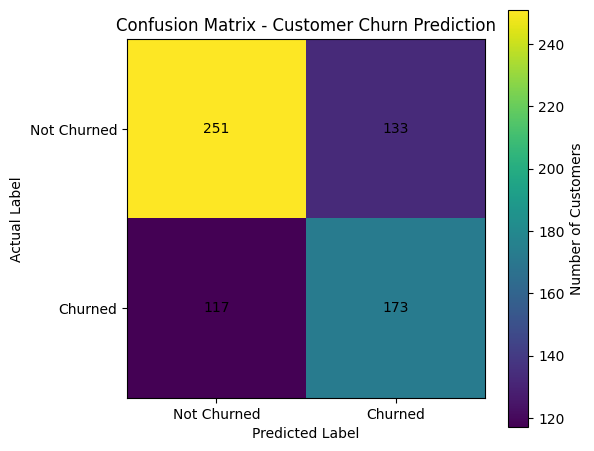

In [100]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - Customer Churn Prediction")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks(
    [0, 1],
    ["Not Churned", "Churned"]
)

plt.yticks(
    [0, 1],
    ["Not Churned", "Churned"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar(label="Number of Customers")
plt.tight_layout()
plt.show()

In [101]:
tn, fp, fn, tp = cm.ravel()

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

True Negatives : 251
False Positives: 133
False Negatives: 117
True Positives : 173


# Feature Importance

In [102]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_classifier.feature_importances_
})

In [103]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

In [104]:
feature_importance

,Feature,Importance
0,Monetary,0.165308
1,Recency,0.157753
2,TotalQuantity,0.147083
3,UniqueProducts,0.141456
4,AverageOrderValue,0.137042
5,AverageQuantityPerOrder,0.129718
6,ActiveDays,0.061441
7,Frequency,0.060199


In [105]:
for _, row in feature_importance.iterrows():
    print(
        f"{row['Feature']}: "
        f"{row['Importance']:.4f}"
    )

Monetary: 0.1653
Recency: 0.1578
TotalQuantity: 0.1471
UniqueProducts: 0.1415
AverageOrderValue: 0.1370
AverageQuantityPerOrder: 0.1297
ActiveDays: 0.0614
Frequency: 0.0602


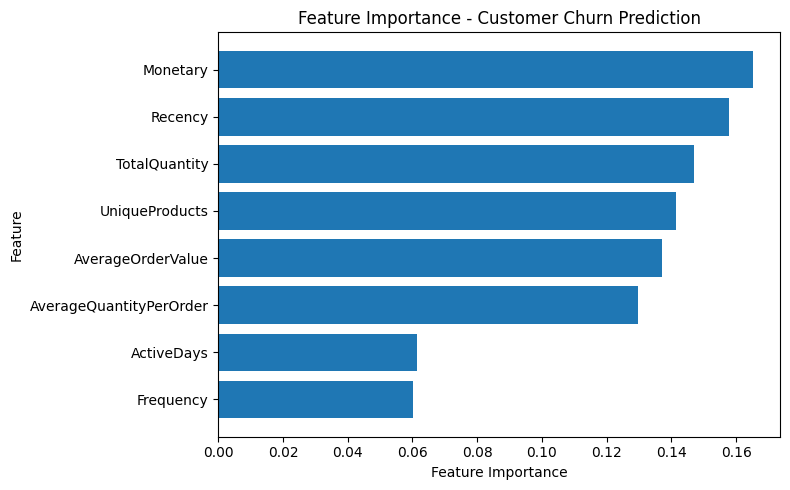

In [106]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Customer Churn Prediction")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [107]:
feature_importance.to_csv(
    "../outputs/churn_feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


# Save and Reload The Model

In [108]:
import joblib
model_path = "../models/churn_model.pkl"
joblib.dump(
    rf_classifier,
    model_path
)

print("Churn model saved successfully.")
print("Model path:", model_path)

Churn model saved successfully.
Model path: ../models/churn_model.pkl


In [109]:
loaded_churn_model = joblib.load(model_path)

print("Saved model loaded successfully.")
print(loaded_churn_model)

Saved model loaded successfully.
RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)


# Test Loaded Model

In [110]:
loaded_predictions = loaded_churn_model.predict(X_test)
print(
    "Predictions identical:",
    np.array_equal(y_pred, loaded_predictions)
)

Predictions identical: True


In [111]:
loaded_probabilities = (
    loaded_churn_model
    .predict_proba(X_test)[:, 1]
)
print("First 10 churn probabilities:")
print(loaded_probabilities[:10])

First 10 churn probabilities:
[0.    0.765 0.225 0.825 0.13  0.715 0.75  0.62  0.545 0.07 ]


In [112]:
print(
    "Probabilities identical:",
    np.allclose(
        churn_probability,
        loaded_probabilities
    )
)

Probabilities identical: True


In [113]:
print("Model type:", type(loaded_churn_model).__name__)
print("Number of trees:", loaded_churn_model.n_estimators)
print("Test samples:", len(X_test))
print("Predictions generated:", len(loaded_predictions))
print(
    "Prediction consistency:",
    np.array_equal(y_pred, loaded_predictions)
)
print(
    "Probability consistency:",
    np.allclose(
        churn_probability,
        loaded_probabilities
    )
)

Model type: RandomForestClassifier
Number of trees: 200
Test samples: 674
Predictions generated: 674
Prediction consistency: True
Probability consistency: True
